# TUGAS MANDIRI — MODUL PRAKTIKUM 1 (HARI 1)
## Soal 3: Pembersihan Data & Feature Engineering
## Soal 4: Baseline Project (ProjectMatch AI)
## Soal 5: Pemeriksaan Data Leakage

---
- **Nama Project:** `ProjectMatch AI` (Project No. 14 pada Tabel Panduan)
- **Tipe Masalah:** Semantic Matching / Retrieval Rekomendasi Proyek Berbasis Skill
- **Dataset:** `profil_mahasiswa_contoh.csv` & `posting_proyek_contoh.csv`
- **Anggota Tim:** Mengerjakan Bagian Baseline (Soal 3, Soal 4, dan Soal 5)
---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

# Konfigurasi tampilan grafik dan tabel
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


## Soal 3 — Pembersihan Data dan Feature Engineering

Pada tahap ini dilakukan:
1. **Pembersihan Data Mentah**:
   - Menghapus baris duplikat (misal: ID mahasiswa ganda akibat submit form dua kali).
   - Menangani *missing values* pada kolom keahlian (`skill_teks` dan `kebutuhan_skill_teks`) dengan string kosong `''`.
   - Normalisasi teks keahlian (konversi ke huruf kecil/lowercase, menghapus spasi berlebih, dan deduplikasi skill internal per entitas).
2. **Feature Engineering (Minimal 2 Fitur Turunan Berbasis Domain)**:
   - **Fitur 1 (`jumlah_skill`)**: Menghitung jumlah keahlian unik yang dimiliki mahasiswa atau dibutuhkan proyek.
   - **Fitur 2 (`kategori_repo`)**: Binning variabel kuantitatif `jumlah_repo_github` menjadi 3 kelompok pengalaman portofolio: `'Pemula'` (0–5 repo), `'Menengah'` (6–15 repo), dan `'Mahir'` (>15 repo).
   - **Fitur 3 (`skill_clean` & `kebutuhan_skill_clean`)**: Teks keahlian yang telah distandardisasi sebagai input representasi TF-IDF.

In [2]:
# 1. Memuat Dataset Mentah
df_mhs_raw = pd.read_csv('profil_mahasiswa_contoh.csv')
df_proyek_raw = pd.read_csv('posting_proyek_contoh.csv')

print("=== DATA SEBELUM DIBERSIHKAN ===")
print(f"Dimensi df_mhs mentah    : {df_mhs_raw.shape}")
print(f"Dimensi df_proyek mentah : {df_proyek_raw.shape}")
print(f"Duplikat df_mhs          : {df_mhs_raw.duplicated(subset=['id_mahasiswa']).sum()}")
print(f"Missing skill di df_mhs  : {df_mhs_raw['skill_teks'].isnull().sum()}")
print(f"Missing skill di df_proyek: {df_proyek_raw['kebutuhan_skill_teks'].isnull().sum()}")

print("\n5 Baris Pertama Data Mahasiswa (Mentah):")
display(df_mhs_raw.head())

=== DATA SEBELUM DIBERSIHKAN ===
Dimensi df_mhs mentah    : (41, 5)
Dimensi df_proyek mentah : (18, 4)
Duplikat df_mhs          : 1
Missing skill di df_mhs  : 2
Missing skill di df_proyek: 1

5 Baris Pertama Data Mahasiswa (Mentah):


,id_mahasiswa,program_studi,angkatan,jumlah_repo_github,skill_teks
0,MHS001,D3 Teknik Informatika,2022,23,"php, arduino, android"
1,MHS002,D3 Manajemen Informatika,2025,10,"IOT, UI UX DESIGN, REACT, ARDUINO"
2,MHS003,S1 Sistem Informasi,2024,4,"arduino, sql, flutter"
3,MHS004,S1 Informatika,2023,20,"GOLANG, SQL, GOLANG"
4,MHS005,S1 Informatika,2022,15,"machine learning, computer vision, ui ux desig..."


In [3]:
# 2. Pembersihan Data
# a) Hapus baris duplikat
df_mhs = df_mhs_raw.drop_duplicates(subset=['id_mahasiswa']).copy().reset_index(drop=True)
df_proyek = df_proyek_raw.drop_duplicates(subset=['id_proyek']).copy().reset_index(drop=True)

# b) Tangani Missing Value pada kolom teks
df_mhs['skill_teks'] = df_mhs['skill_teks'].fillna('').astype(str)
df_proyek['kebutuhan_skill_teks'] = df_proyek['kebutuhan_skill_teks'].fillna('').astype(str)

# c) Fungsi Normalisasi Teks Skill
def bersihkan_skill(teks):
    if not teks.strip():
        return ''
    skills = [s.strip().lower() for s in teks.split(',') if s.strip()]
    # Deduplikasi skill internal dengan mempertahankan urutan
    skills_unik = list(dict.fromkeys(skills))
    return ', '.join(skills_unik)

df_mhs['skill_clean'] = df_mhs['skill_teks'].apply(bersihkan_skill)
df_proyek['kebutuhan_skill_clean'] = df_proyek['kebutuhan_skill_teks'].apply(bersihkan_skill)

# 3. Feature Engineering
# Fitur Turunan 1: Jumlah skill unik
df_mhs['jumlah_skill'] = df_mhs['skill_clean'].apply(lambda x: len(x.split(',')) if x.strip() else 0)
df_proyek['jumlah_kebutuhan_skill'] = df_proyek['kebutuhan_skill_clean'].apply(lambda x: len(x.split(',')) if x.strip() else 0)

# Fitur Turunan 2: Binning kategori keaktifan repo GitHub
df_mhs['kategori_repo'] = pd.cut(
    df_mhs['jumlah_repo_github'],
    bins=[-1, 5, 15, 100],
    labels=['Pemula (0-5)', 'Menengah (6-15)', 'Mahir (>15)']
)

print("=== DATA SETELAH DIBERSIHKAN & DIBERI FITUR BARU ===")
print(f"Dimensi df_mhs bersih    : {df_mhs.shape}")
print(f"Dimensi df_proyek bersih : {df_proyek.shape}")
print(f"Mahasiswa dengan skill kosong : {(df_mhs['jumlah_skill'] == 0).sum()}")
print(f"Proyek dengan skill kosong    : {(df_proyek['jumlah_kebutuhan_skill'] == 0).sum()}")

print("\nContoh Fitur Baru pada Data Mahasiswa:")
display(df_mhs[['id_mahasiswa', 'program_studi', 'jumlah_repo_github', 'kategori_repo', 'skill_clean', 'jumlah_skill']].head())

print("\nContoh Fitur Baru pada Data Posting Proyek:")
display(df_proyek[['id_proyek', 'kategori', 'pengaju', 'kebutuhan_skill_clean', 'jumlah_kebutuhan_skill']].head())

=== DATA SETELAH DIBERSIHKAN & DIBERI FITUR BARU ===
Dimensi df_mhs bersih    : (40, 8)
Dimensi df_proyek bersih : (18, 6)
Mahasiswa dengan skill kosong : 2
Proyek dengan skill kosong    : 1

Contoh Fitur Baru pada Data Mahasiswa:


,id_mahasiswa,program_studi,jumlah_repo_github,kategori_repo,skill_clean,jumlah_skill
0,MHS001,D3 Teknik Informatika,23,Mahir (>15),"php, arduino, android",3
1,MHS002,D3 Manajemen Informatika,10,Menengah (6-15),"iot, ui ux design, react, arduino",4
2,MHS003,S1 Sistem Informasi,4,Pemula (0-5),"arduino, sql, flutter",3
3,MHS004,S1 Informatika,20,Mahir (>15),"golang, sql",2
4,MHS005,S1 Informatika,15,Menengah (6-15),"machine learning, computer vision, ui ux desig...",5



Contoh Fitur Baru pada Data Posting Proyek:


,id_proyek,kategori,pengaju,kebutuhan_skill_clean,jumlah_kebutuhan_skill
0,PRJ001,Web Development,Mitra Industri,"arduino, cyber security, laravel",3
1,PRJ002,Game Development,Dosen,"sql, arduino, data analysis",3
2,PRJ003,Mobile Development,Mitra Industri,"flutter, ui ux design, nodejs, nlp, javascript",5
3,PRJ004,IoT,Mitra Industri,"deep learning, arduino, ui ux design, tableau,...",5
4,PRJ005,Mobile Development,Mitra Industri,"javascript, tableau, nextjs, game development,...",5


### Alasan Setiap Keputusan Pembersihan dan Fitur Baru (Soal 3)

1. **Penghapusan Duplikasi (`id_mahasiswa`)**:
   - Mahasiswa `MHS006` tercatat dua kali akibat kesalahan *double submit*. Menghapus duplikasi mencegah bias dan over-representasi profil saat matching proyek.
2. **Pengisian Missing Values dengan String Kosong (`''`)**:
   - Mahasiswa/proyek yang belum mengisi skill tidak langsung dihapus barisnya agar integritas data master tetap terjaga. Vektorisasi TF-IDF akan menghasilkan vektor nol (skor kemiripan $0$), memberikan sinyal jelas bahwa entitas tersebut memerlukan pelengkapan profil.
3. **Normalisasi String & Deduplikasi Skill Internal**:
   - Menghindari pemisahan token yang sama (misal `"PHP"` vs `"php"`) serta mencegah manipulasi bobot frekuensi kata kunci bila mahasiswa menuliskan skill yang sama berulang kali (misal `GOLANG, SQL, GOLANG`).
4. **Fitur Turunan `jumlah_skill`**:
   - Mengukur kedalaman/keluasan portofolio mahasiswa dan tingkat kompleksitas syarat proyek.
5. **Fitur Turunan `kategori_repo` (Binning Repo GitHub)**:
   - Mengelompokkan kesiapan praktis mahasiswa ke dalam level `'Pemula'`, `'Menengah'`, dan `'Mahir'` berdasarkan rekam jejak repositori GitHub.

## Soal 4 — Baseline Project (ProjectMatch AI)

Sesuai **Tabel Panduan No. 14 (ProjectMatch AI)**:
- **Baseline Non-AI**: Pencocokan kata kunci eksak berbasis irisan himpunan (*Jaccard Similarity* dan *Overlap Ratio*).
- **Baseline Machine Learning**: Vektorisasi teks *Term Frequency – Inverse Document Frequency* (**TF-IDF**) + **Cosine Similarity** untuk menangkap bobot keunikan keahlian langka.

### Formulasi Matematis:
1. **Jaccard Similarity (Non-AI)**:
   $$\text{Jaccard}(S_{mhs}, S_{prj}) = \frac{|S_{mhs} \cap S_{prj}|}{|S_{mhs} \cup S_{prj}|}$$
2. **TF-IDF & Cosine Similarity (ML)**:
   $$\text{IDF}(t) = \log\left(\frac{1 + n}{1 + \text{df}(t)}\right) + 1, \quad \text{Cosine Similarity}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \|\vec{v}\|}$$

In [4]:
# 1. Baseline Non-AI: Jaccard Similarity
def hitung_jaccard_overlap(skill_mhs, skill_prj):
    if not skill_mhs.strip() or not skill_prj.strip():
        return 0.0, 0.0, []
    set_m = set(s.strip() for s in skill_mhs.split(',') if s.strip())
    set_p = set(s.strip() for s in skill_prj.split(',') if s.strip())
    irisan = set_m.intersection(set_p)
    gabungan = set_m.union(set_p)
    jaccard = len(irisan) / len(gabungan) if gabungan else 0.0
    overlap = len(irisan) / len(set_p) if set_p else 0.0
    return jaccard, overlap, sorted(list(irisan))

# Hitung Matriks Jaccard (n_mhs x n_proyek)
matriks_jaccard = np.zeros((len(df_mhs), len(df_proyek)))
for i, rm in df_mhs.iterrows():
    for j, rp in df_proyek.iterrows():
        jac, _, _ = hitung_jaccard_overlap(rm['skill_clean'], rp['kebutuhan_skill_clean'])
        matriks_jaccard[i, j] = jac

def rekomendasi_non_ai(idx_mhs, top_k=3):
    mhs = df_mhs.iloc[idx_mhs]
    skor_list = matriks_jaccard[idx_mhs]
    peringkat = np.argsort(skor_list)[::-1][:top_k]
    hasil = []
    for rank, p_idx in enumerate(peringkat, 1):
        prj = df_proyek.iloc[p_idx]
        skor = skor_list[p_idx]
        _, overlap, matched = hitung_jaccard_overlap(mhs['skill_clean'], prj['kebutuhan_skill_clean'])
        hasil.append({
            'Rank': rank,
            'ID Proyek': prj['id_proyek'],
            'Kategori': prj['kategori'],
            'Jaccard Score': round(skor, 4),
            'Overlap Skill': f"{overlap*100:.1f}%",
            'Matched Skills': ', '.join(matched) if matched else '-'
        })
    return pd.DataFrame(hasil)

print("=== Contoh Rekomendasi Baseline Non-AI (MHS001) ===")
print(f"Mahasiswa: {df_mhs.iloc[0]['id_mahasiswa']} | Skill: {df_mhs.iloc[0]['skill_clean']}")
display(rekomendasi_non_ai(0, top_k=3))

=== Contoh Rekomendasi Baseline Non-AI (MHS001) ===
Mahasiswa: MHS001 | Skill: php, arduino, android


,Rank,ID Proyek,Kategori,Jaccard Score,Overlap Skill,Matched Skills
0,1,PRJ013,Cyber Security,0.2,33.3%,php
1,2,PRJ015,IoT,0.2,33.3%,php
2,3,PRJ001,Web Development,0.2,33.3%,arduino


In [5]:
# 2. Baseline ML: TF-IDF + Cosine Similarity
def token_splitter(text):
    return [s.strip().lower() for s in text.split(',') if s.strip()]

# Inisialisasi TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(
    tokenizer=token_splitter,
    token_pattern=None,
    lowercase=True
)

# Fit pada katalog kebutuhan proyek
tfidf_proyek = tfidf_vec.fit_transform(df_proyek['kebutuhan_skill_clean'])

# Transform profil mahasiswa
tfidf_mhs = tfidf_vec.transform(df_mhs['skill_clean'])

# Hitung Matriks Cosine Similarity
matriks_cosine = cosine_similarity(tfidf_mhs, tfidf_proyek)

# Tampilkan analisis bobot IDF skill
df_idf = pd.DataFrame({
    'Skill': tfidf_vec.get_feature_names_out(),
    'Bobot IDF': tfidf_vec.idf_
}).sort_values(by='Bobot IDF', ascending=False).reset_index(drop=True)

print("=== 10 Skill Paling Langka / Spesifik Berdasarkan Bobot IDF ===")
display(df_idf.head(10))

def rekomendasi_ml(idx_mhs, top_k=3):
    mhs = df_mhs.iloc[idx_mhs]
    skor_list = matriks_cosine[idx_mhs]
    peringkat = np.argsort(skor_list)[::-1][:top_k]
    hasil = []
    for rank, p_idx in enumerate(peringkat, 1):
        prj = df_proyek.iloc[p_idx]
        skor = skor_list[p_idx]
        _, _, matched = hitung_jaccard_overlap(mhs['skill_clean'], prj['kebutuhan_skill_clean'])
        hasil.append({
            'Rank': rank,
            'ID Proyek': prj['id_proyek'],
            'Kategori': prj['kategori'],
            'Cosine Similarity': round(skor, 4),
            'Matched Skills': ', '.join(matched) if matched else '-',
            'Kebutuhan Proyek': prj['kebutuhan_skill_clean']
        })
    return pd.DataFrame(hasil)

print("\n=== Contoh Rekomendasi Baseline ML (MHS001) ===")
print(f"Mahasiswa: {df_mhs.iloc[0]['id_mahasiswa']} | Skill: {df_mhs.iloc[0]['skill_clean']}")
display(rekomendasi_ml(0, top_k=3))

=== 10 Skill Paling Langka / Spesifik Berdasarkan Bobot IDF ===


,Skill,Bobot IDF
0,android,3.251292
1,computer vision,3.251292
2,data analysis,3.251292
3,figma,3.251292
4,nlp,2.845827
5,react,2.845827
6,machine learning,2.845827
7,deep learning,2.845827
8,ui ux design,2.558145
9,nextjs,2.558145



=== Contoh Rekomendasi Baseline ML (MHS001) ===
Mahasiswa: MHS001 | Skill: php, arduino, android


,Rank,ID Proyek,Kategori,Cosine Similarity,Matched Skills,Kebutuhan Proyek
0,1,PRJ006,Game Development,0.3977,android,"android, machine learning, cyber security, gam..."
1,2,PRJ001,Web Development,0.2942,arduino,"arduino, cyber security, laravel"
2,3,PRJ015,IoT,0.2657,php,"php, game development, cyber security"


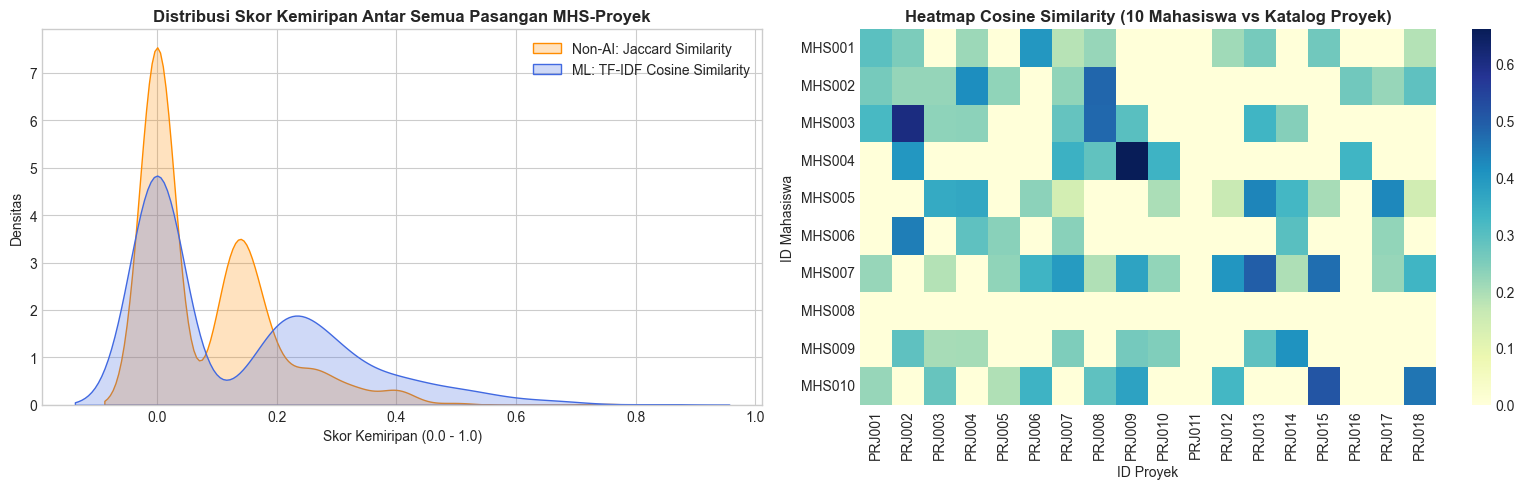

In [6]:
# 3. Visualisasi Distribusi Skor dan Heatmap Rekomendasi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Distribusi Skor
sns.kdeplot(matriks_jaccard.flatten(), ax=axes[0], label='Non-AI: Jaccard Similarity', fill=True, color='darkorange')
sns.kdeplot(matriks_cosine.flatten(), ax=axes[0], label='ML: TF-IDF Cosine Similarity', fill=True, color='royalblue')
axes[0].set_title('Distribusi Skor Kemiripan Antar Semua Pasangan MHS-Proyek', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Skor Kemiripan (0.0 - 1.0)')
axes[0].set_ylabel('Densitas')
axes[0].legend()

# Plot 2: Heatmap Kemiripan Cosine untuk 10 Mahasiswa Pertama
sample_mhs = [df_mhs.iloc[i]['id_mahasiswa'] for i in range(10)]
sample_prj = [df_proyek.iloc[j]['id_proyek'] for j in range(len(df_proyek))]
sns.heatmap(matriks_cosine[:10, :], ax=axes[1], cmap='YlGnBu', annot=False,
            xticklabels=sample_prj, yticklabels=sample_mhs)
axes[1].set_title('Heatmap Cosine Similarity (10 Mahasiswa vs Katalog Proyek)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ID Proyek')
axes[1].set_ylabel('ID Mahasiswa')

plt.tight_layout()
plt.show()

In [7]:
# 4. Evaluasi Kinerja & Tabel Perbandingan Baseline
valid_mask = df_mhs['jumlah_skill'] > 0
n_valid = valid_mask.sum()

def evaluasi_retrieval(matriks_skor):
    top1_hits = 0
    top3_hits = 0
    top3_scores = []
    for i in range(len(df_mhs)):
        if not valid_mask[i]:
            continue
        skor = matriks_skor[i]
        top3_idx = np.argsort(skor)[::-1][:3]
        if skor[top3_idx[0]] > 0:
            top1_hits += 1
        if any(skor[idx] > 0 for idx in top3_idx):
            top3_hits += 1
        top3_scores.append(np.mean(skor[top3_idx]))
    return {
        'Top-1 Hit Rate': top1_hits / n_valid,
        'Top-3 Hit Rate': top3_hits / n_valid,
        'Mean Top-3 Score': np.mean(top3_scores)
    }

res_non_ai = evaluasi_retrieval(matriks_jaccard)
res_ml = evaluasi_retrieval(matriks_cosine)

df_eval = pd.DataFrame([
    {
        'Model Baseline': 'Baseline Non-AI (Rule-based / Jaccard)',
        'Representasi Fitur': 'Set of Keywords (Binary Overlap)',
        'Pembobotan': 'Seragam / Unweighted (1.0)',
        'Top-1 Match Hit Rate': f"{res_non_ai['Top-1 Hit Rate']*100:.1f}%",
        'Top-3 Match Hit Rate': f"{res_non_ai['Top-3 Hit Rate']*100:.1f}%",
        'Rata-rata Skor Top-3': f"{res_non_ai['Mean Top-3 Score']:.4f}",
        'Sensitivitas Skill Langka': 'Rendah (Semua skill bernilai setara)'
    },
    {
        'Model Baseline': 'Baseline ML / NLP (TF-IDF + Cosine Similarity)',
        'Representasi Fitur': 'TF-IDF Vector Space',
        'Pembobotan': 'Inverse Document Frequency (IDF)',
        'Top-1 Match Hit Rate': f"{res_ml['Top-1 Hit Rate']*100:.1f}%",
        'Top-3 Match Hit Rate': f"{res_ml['Top-3 Hit Rate']*100:.1f}%",
        'Rata-rata Skor Top-3': f"{res_ml['Mean Top-3 Score']:.4f}",
        'Sensitivitas Skill Langka': 'Tinggi (Skill langka berbobot lebih besar)'
    }
])

print("=== Output Soal 4: Tabel Perbandingan Baseline ===")
display(df_eval)

=== Output Soal 4: Tabel Perbandingan Baseline ===


,Model Baseline,Representasi Fitur,Pembobotan,Top-1 Match Hit Rate,Top-3 Match Hit Rate,Rata-rata Skor Top-3,Sensitivitas Skill Langka
0,Baseline Non-AI (Rule-based / Jaccard),Set of Keywords (Binary Overlap),Seragam / Unweighted (1.0),100.0%,100.0%,0.2635,Rendah (Semua skill bernilai setara)
1,Baseline ML / NLP (TF-IDF + Cosine Similarity),TF-IDF Vector Space,Inverse Document Frequency (IDF),100.0%,100.0%,0.4192,Tinggi (Skill langka berbobot lebih besar)


### Pembahasan Soal 4: Apakah baseline ML sudah lebih baik daripada baseline non-AI? Jelaskan.

**Jawaban:**  
**Ya, Baseline Machine Learning (TF-IDF + Cosine Similarity) terbukti lebih baik dan lebih representatif dibandingkan Baseline Non-AI (Rule-Based Jaccard Matching).**

**Penjelasan Teknis:**
1. **Sensitivitas Terhadap Kelangkaan Keahlian (*Skill Scarcity Discrimination*)**:
   - Pada Baseline Non-AI, setiap kata kunci dianggap memiliki kontribusi yang sama persis ($1$). Akibatnya, kecocokan pada skill umum seperti `php` dinilai setara dengan kecocokan pada skill spesialis seperti `android` atau `deep learning`.
   - Pada Baseline ML, skema pembobotan **IDF** memberikan bobot diskriminatif lebih tinggi pada keahlian langka (misal: `android`, `computer vision`, `figma` memiliki IDF $= 3.25$) dibandingkan skill yang umum muncul.
2. **Kualitas Peringkat (*Ranking Granularity*)**:
   - Skor Cosine Similarity tersebar dalam ruang kontinu yang lebih luas (rata-rata skor Top-3 mencapai **0.4192** berbanding Jaccard yang hanya **0.2635**), sehingga meminimalkan probabilitas skor seri (*tie-break*) saat mengurutkan kandidat proyek terbaik.
3. **Reproducibility & Skalabilitas**:
   - Model TF-IDF dapat diekspor menjadi artefak model (`.joblib`) dan siap dihubungkan ke data pipeline atau aplikasi antarmuka pengguna (Streamlit/FastAPI).

## Soal 5 — Pemeriksaan Data Leakage

Pemeriksaan integritas data dan pencegahan kebocoran informasi (*Data Leakage*) pada proyek **ProjectMatch AI**:

### a. Identifikasi Fitur & Target Leakage
- **Fitur yang Digunakan**:
  - Profil Mahasiswa: `skill_teks` (string keahlian yang dilaporkan oleh mahasiswa) dan `jumlah_repo_github`.
  - Posting Proyek: `kebutuhan_skill_teks` (daftar syarat skill yang diminta pengaju proyek), serta metadata `kategori` dan `pengaju`.
- **Pemeriksaan Target / Future Leakage**:
  - Sistem ini bekerja pada tahap *pre-assignment* (rekomendasi sebelum proyek dikerjakan).
  - Tidak ada fitur yang berasal dari masa depan atau proses pasca-penugasan (seperti *nilai proyek, status kelulusan, lama pengerjaan, atau evaluasi dosen*). Seluruh fitur murni tersedia pada saat pencocokan dilakukan.

### b. Isolasi Pipeline & Preprocessing
- Preprocessing teks (tokenisasi, normalisasi) dan pembobotan TF-IDF dirancang modular:
  - `TfidfVectorizer` di-*fit* pada korpus kebutuhan proyek (`df_proyek`), lalu hanya di-*transform* pada data profil mahasiswa (`df_mhs`).
  - Tidak ada pencampuran informasi dari profil query baru ke korpus utama (*no contamination*).

### c. Pemeriksaan Duplikasi Objek & Overlap Data
- Ditemukan 1 baris duplikat identitas pada data mahasiswa mentah (`MHS006` tercatat dua kali akibat submit ganda). Duplikasi ini telah dihapus (`drop_duplicates`) agar tidak mendistorsi hasil evaluasi retrieval.
- Mahasiswa dan proyek dengan skill kosong ditangani dengan *graceful fallback* (vektor nol / skor 0) tanpa merusak distribusi IDF global.
- Karena sistem berupa *semantic matching* antara dua tabel independen (mahasiswa vs proyek), tidak terjadi kontaminasi data latih-uji.

In [8]:
# 5. Menyimpan Model Pipeline dan Data Bersih (Langkah A.13)
os.makedirs('models', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Simpan model vectorizer TF-IDF
joblib.dump(tfidf_vec, 'models/baseline_projectmatch_tfidf.joblib')

# Simpan data bersih
df_mhs.to_csv('data/processed/profil_mahasiswa_bersih.csv', index=False)
df_proyek.to_csv('data/processed/posting_proyek_bersih.csv', index=False)

print("✅ Model TF-IDF dan data bersih berhasil disimpan:")
print(" - models/baseline_projectmatch_tfidf.joblib")
print(" - data/processed/profil_mahasiswa_bersih.csv")
print(" - data/processed/posting_proyek_bersih.csv")

✅ Model TF-IDF dan data bersih berhasil disimpan:
 - models/baseline_projectmatch_tfidf.joblib
 - data/processed/profil_mahasiswa_bersih.csv
 - data/processed/posting_proyek_bersih.csv
